# Crime Prediction using Artificial Intelligence
## Final Notebook

This notebook includes:
- one upload point for one combined CSV dataset
- data inspection and preparation
- train / validation / test split
- monthly crime trend and crime-type heatmap
- baseline Decision Tree
- Random Forest, SVM, and CNN comparison
- accuracy, F1 score, classification report, confusion matrix, ROC and AUC
- feature selection
- SMOTE class balancing
- hyperparameter tuning
- Neural Network (MLP)
- XGBoost
- cross validation
- final model selection
- prediction pipeline for new inputs

**Target task:** predict `Crime type`


In [1]:

pip install imbalanced-learn xgboost


In [2]:
import io
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option("display.max_columns", None)
print("Imports loaded successfully.")


Imports loaded successfully.


## 1. Single upload point

Run the next cell and upload your combined CSV file.


In [3]:
df = None

try:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise ValueError("No file uploaded.")
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Loaded file: {file_name}")
    print("Dataset shape:", df.shape)
    display(df.head())

except Exception:
    import ipywidgets as widgets

    uploader = widgets.FileUpload(accept=".csv", multiple=False)
    display(uploader)

    def load_uploaded(change):
        global df
        if not uploader.value:
            return

        value = uploader.value
        if isinstance(value, dict):
            file_info = list(value.values())[0]
            content = file_info["content"]
            file_name = file_info["name"]
        else:
            file_info = value[0]
            content = file_info["content"]
            file_name = file_info["name"]

        df = pd.read_csv(io.BytesIO(content))
        print(f"Loaded file: {file_name}")
        print("Dataset shape:", df.shape)
        display(df.head())

    uploader.observe(load_uploaded, names="value")
    print("Upload your combined CSV using the button above, then continue.")


Saving combine.csv to combine.csv
Loaded file: combine.csv
Dataset shape: (300547, 13)


,File,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,2025-01-west-yorkshire-street.csv,NaN,2025-01,West Yorkshire Police,West Yorkshire Police,-1.472961,53.599861,On or near Railway Walk,E01007439,Barnsley 001D,Anti-social behaviour,NaN,NaN
1,2025-01-west-yorkshire-street.csv,03b3bda6de7c51f6cd0820b7f998a1f878e7acbb6b18dd...,2025-01,West Yorkshire Police,West Yorkshire Police,-1.882755,53.924927,On or near Moorside Lane,E01010646,Bradford 001A,Burglary,Investigation complete; no suspect identified,NaN
2,2025-01-west-yorkshire-street.csv,6f9fe9a78c7ed106fadb658e4fd5313c1bb5bc5c8aa223...,2025-01,West Yorkshire Police,West Yorkshire Police,-1.878940,53.943744,On or near Cross End Fold,E01010646,Bradford 001A,Shoplifting,Investigation complete; no suspect identified,NaN
3,2025-01-west-yorkshire-street.csv,9cbc69a540485581b55d8d4723eb41b97d364bc98132d8...,2025-01,West Yorkshire Police,West Yorkshire Police,-1.872959,53.941733,On or near Cornerstones Close,E01010646,Bradford 001A,Vehicle crime,Investigation complete; no suspect identified,NaN
4,2025-01-west-yorkshire-street.csv,050a7cc33129f37f41cbbd38fe858e63e07dc239720be8...,2025-01,West Yorkshire Police,West Yorkshire Police,-1.883567,53.934131,On or near Cocking Lane,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN


In [4]:
if df is None:
    print("Please upload the dataset first and then rerun this cell.")
else:
    print("Columns in dataset:")
    print(df.columns.tolist())
    print("\nTop missing values:")
    display(df.isnull().sum().sort_values(ascending=False).head(20))


Columns in dataset:
['File', 'Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']

Top missing values:


,0
Context,300547
Last outcome category,27907
Crime ID,27907
Latitude,2162
Longitude,2162
LSOA name,2162
LSOA code,2162
Month,0
File,0
Falls within,0


## 2. Prepare dataset

In [5]:
if df is None:
    raise ValueError("Please upload the dataset first.")

if "Crime type" not in df.columns:
    raise ValueError("Dataset must contain 'Crime type' column.")

work_df = df.copy()

if "Month" in work_df.columns:
    work_df["Month"] = pd.to_datetime(work_df["Month"], errors="coerce")
    work_df["Year"] = work_df["Month"].dt.year
    work_df["Month_num"] = work_df["Month"].dt.month
    work_df["Quarter"] = work_df["Month"].dt.quarter

keep_cols = [c for c in [
    "Crime type",
    "Latitude",
    "Longitude",
    "Year",
    "Month_num",
    "Quarter",
    "LSOA code",
    "Last outcome category"
] if c in work_df.columns]

work_df = work_df[keep_cols].dropna(subset=["Crime type"]).drop_duplicates().reset_index(drop=True)

if len(work_df) > 20000:
    work_df = work_df.sample(n=20000, random_state=42)

print("Prepared dataset shape:", work_df.shape)
display(work_df.head())


Prepared dataset shape: (20000, 8)


,Crime type,Latitude,Longitude,Year,Month_num,Quarter,LSOA code,Last outcome category
104532,Other theft,53.724169,-1.714605,2025,6,2,E01011061,Investigation complete; no suspect identified
135463,Violence and sexual offences,53.746186,-1.594410,2025,7,3,E01032489,Status update unavailable
8665,Vehicle crime,53.629051,-1.780162,2025,1,1,E01011226,Investigation complete; no suspect identified
124962,Violence and sexual offences,53.715286,-1.885050,2025,7,3,E01011003,Unable to prosecute suspect
200161,Violence and sexual offences,53.672485,-1.528758,2025,10,4,E01011901,Investigation complete; no suspect identified


## 3. Visualisations

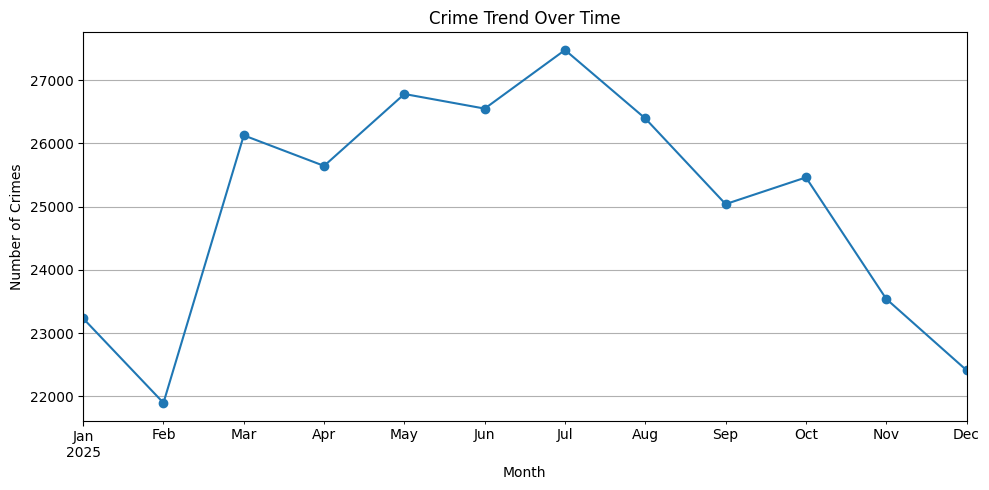

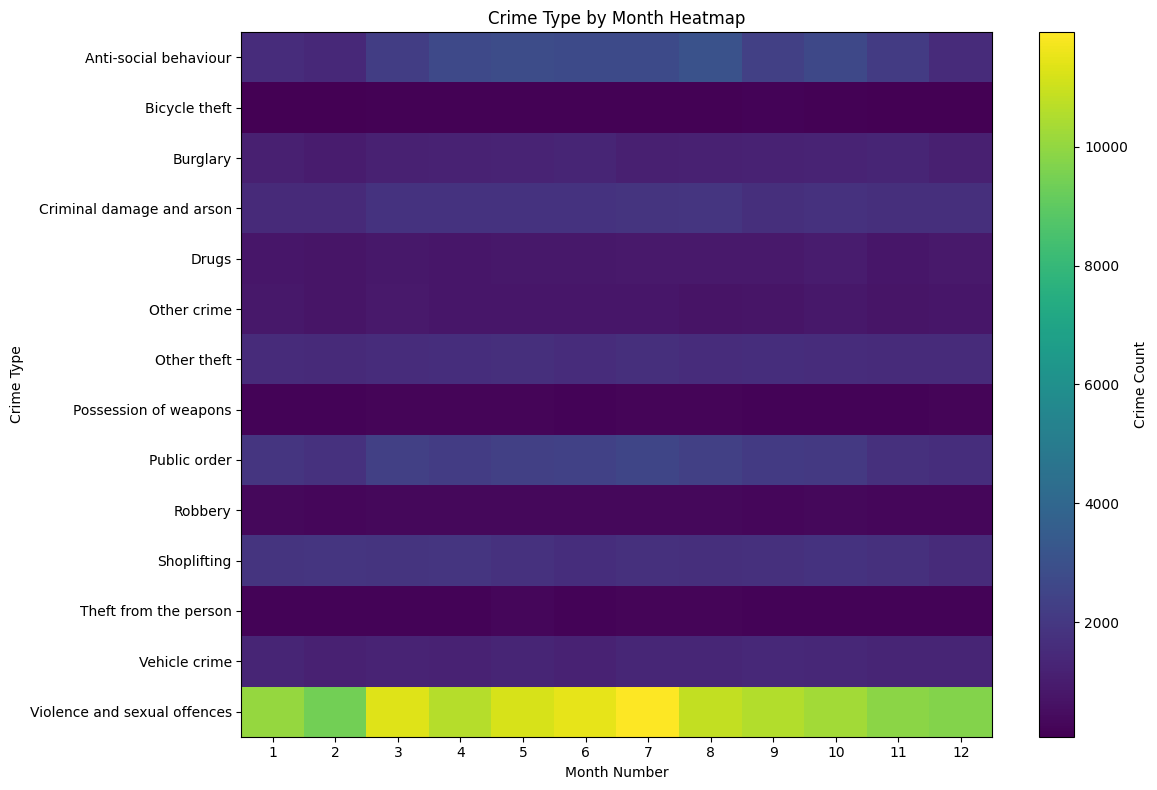

In [6]:
vis_df = df.copy()

if "Month" in vis_df.columns and "Crime type" in vis_df.columns:
    vis_df["Month"] = pd.to_datetime(vis_df["Month"], errors="coerce")

    monthly_counts = vis_df.groupby("Month").size().sort_index()
    plt.figure(figsize=(10, 5))
    monthly_counts.plot(kind="line", marker="o")
    plt.title("Crime Trend Over Time")
    plt.xlabel("Month")
    plt.ylabel("Number of Crimes")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    vis_df["Month_num"] = vis_df["Month"].dt.month
    heatmap_df = (
        vis_df.groupby(["Crime type", "Month_num"]).size()
        .reset_index(name="Count")
        .pivot(index="Crime type", columns="Month_num", values="Count")
        .fillna(0)
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(heatmap_df, aspect="auto")
    plt.colorbar(label="Crime Count")
    plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns)
    plt.title("Crime Type by Month Heatmap")
    plt.xlabel("Month Number")
    plt.ylabel("Crime Type")
    plt.tight_layout()
    plt.show()
else:
    print("Month and Crime type columns are required for trend and heatmap visualisations.")


## 4. Split data and preprocess

In [7]:
X = work_df.drop(columns=["Crime type"])
y = work_df["Crime type"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Processed train shape:", X_train_processed.shape)


Train shape: (14000, 7)
Validation shape: (3000, 7)
Test shape: (3000, 7)
Processed train shape: (14000, 39)


## 5. Helper functions

In [8]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average="weighted")
    }

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def multiclass_auc(y_true, y_score, model_name):
    classes = np.unique(y_true)
    y_true_bin = label_binarize(y_true, classes=classes)

    plt.figure(figsize=(8, 6))
    auc_scores = []

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        score = auc(fpr, tpr)
        auc_scores.append(score)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={score:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curves - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    return float(np.mean(auc_scores))


## 6. Baseline model — Decision Tree

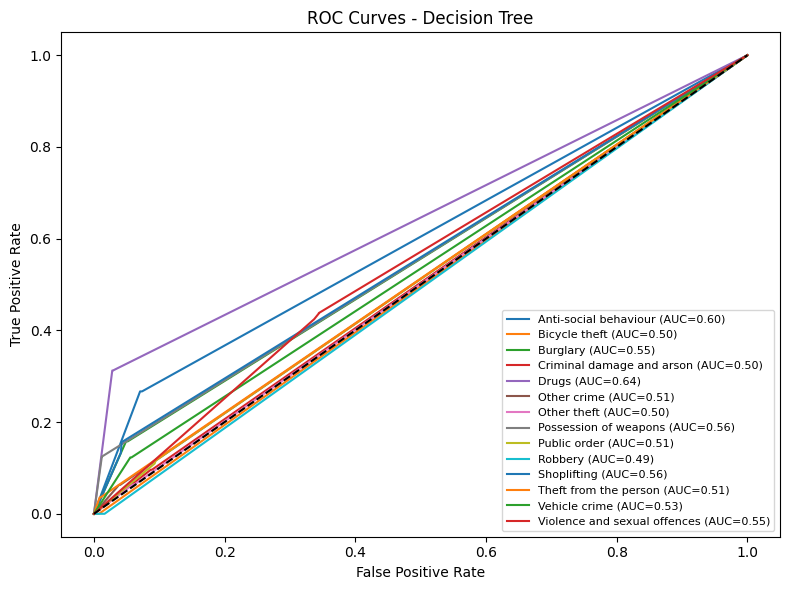

,Model,Accuracy,F1 Score
0,Decision Tree,0.254,0.258141


                              precision    recall  f1-score   support

       Anti-social behaviour       0.27      0.27      0.27       281
               Bicycle theft       0.00      0.00      0.00        17
                    Burglary       0.16      0.16      0.16       171
   Criminal damage and arson       0.08      0.10      0.09       229
                       Drugs       0.29      0.31      0.30       112
                 Other crime       0.06      0.06      0.06       111
                 Other theft       0.07      0.06      0.07       203
       Possession of weapons       0.10      0.12      0.11        32
                Public order       0.11      0.12      0.11       274
                     Robbery       0.00      0.00      0.00        45
                 Shoplifting       0.14      0.15      0.14       128
       Theft from the person       0.04      0.04      0.04        28
               Vehicle crime       0.12      0.12      0.12       179
Violence and sexual

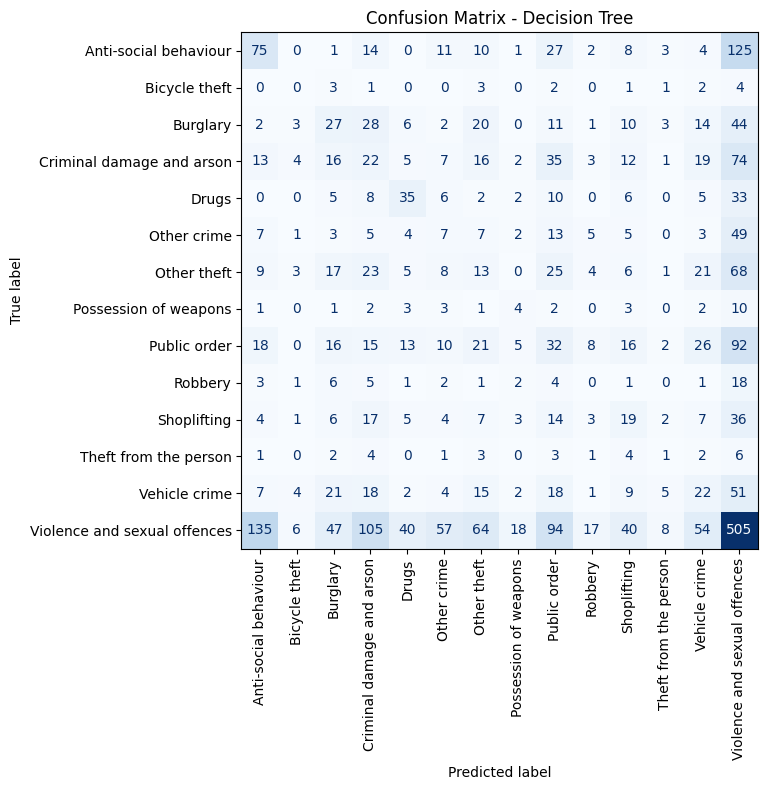

Decision Tree AUC: 0.5365526753289875


In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)

dt_pred = dt_model.predict(X_test_processed)
dt_proba = dt_model.predict_proba(X_test_processed)

dt_metrics = get_metrics(y_test, dt_pred, "Decision Tree")
dt_auc = multiclass_auc(y_test, dt_proba, "Decision Tree")
display(pd.DataFrame([dt_metrics]))

print(classification_report(y_test, dt_pred, target_names=label_encoder.classes_, zero_division=0))
plot_confusion(y_test, dt_pred, "Confusion Matrix - Decision Tree")
print("Decision Tree AUC:", dt_auc)


## 7. Random Forest

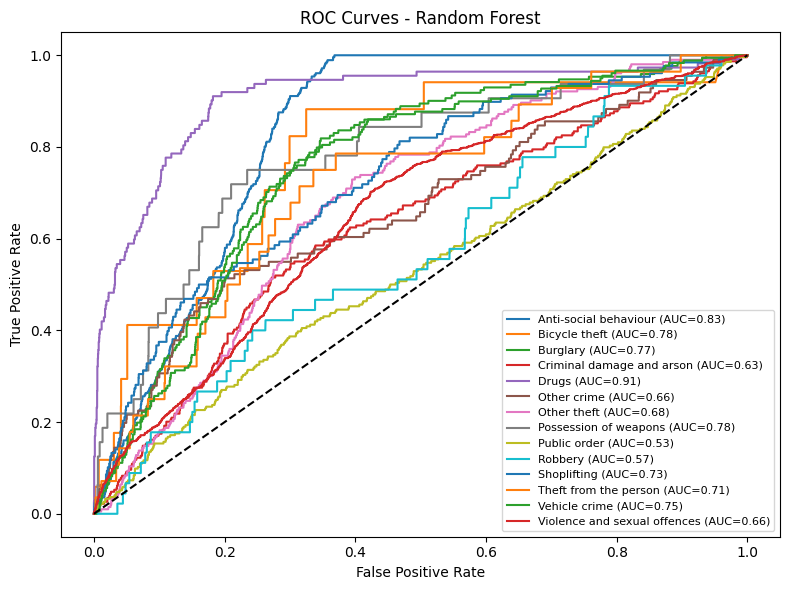

,Model,Accuracy,F1 Score
0,Random Forest,0.391333,0.265529


                              precision    recall  f1-score   support

       Anti-social behaviour       0.10      0.00      0.01       281
               Bicycle theft       0.00      0.00      0.00        17
                    Burglary       0.10      0.04      0.05       171
   Criminal damage and arson       0.13      0.03      0.04       229
                       Drugs       0.57      0.40      0.47       112
                 Other crime       0.00      0.00      0.00       111
                 Other theft       0.04      0.00      0.01       203
       Possession of weapons       0.00      0.00      0.00        32
                Public order       0.16      0.02      0.04       274
                     Robbery       0.00      0.00      0.00        45
                 Shoplifting       0.15      0.05      0.08       128
       Theft from the person       0.00      0.00      0.00        28
               Vehicle crime       0.16      0.07      0.09       179
Violence and sexual

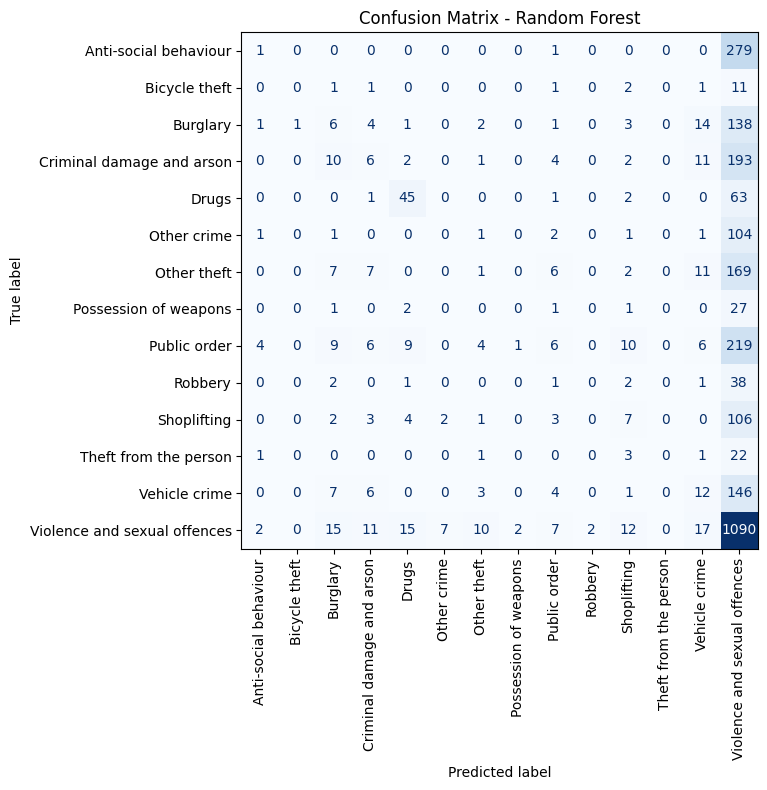

Random Forest AUC: 0.713774649417255


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)
rf_proba = rf_model.predict_proba(X_test_processed)

rf_metrics = get_metrics(y_test, rf_pred, "Random Forest")
rf_auc = multiclass_auc(y_test, rf_proba, "Random Forest")
display(pd.DataFrame([rf_metrics]))

print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_, zero_division=0))
plot_confusion(y_test, rf_pred, "Confusion Matrix - Random Forest")
print("Random Forest AUC:", rf_auc)


## 8. SVM

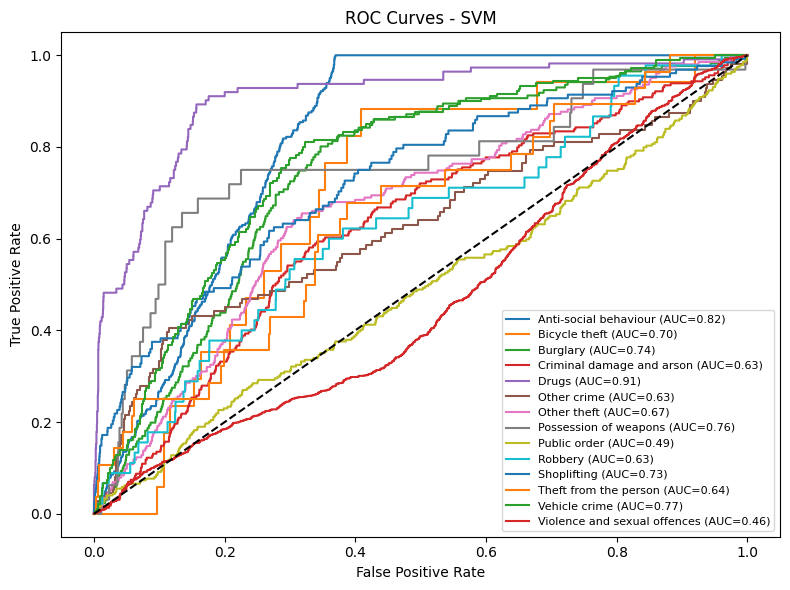

,Model,Accuracy,F1 Score
0,SVM,0.408,0.246863


                              precision    recall  f1-score   support

       Anti-social behaviour       0.25      0.00      0.01       281
               Bicycle theft       0.00      0.00      0.00        17
                    Burglary       0.00      0.00      0.00       171
   Criminal damage and arson       0.00      0.00      0.00       229
                       Drugs       0.63      0.40      0.49       112
                 Other crime       0.00      0.00      0.00       111
                 Other theft       0.00      0.00      0.00       203
       Possession of weapons       0.00      0.00      0.00        32
                Public order       0.20      0.00      0.01       274
                     Robbery       0.00      0.00      0.00        45
                 Shoplifting       0.00      0.00      0.00       128
       Theft from the person       0.00      0.00      0.00        28
               Vehicle crime       0.00      0.00      0.00       179
Violence and sexual

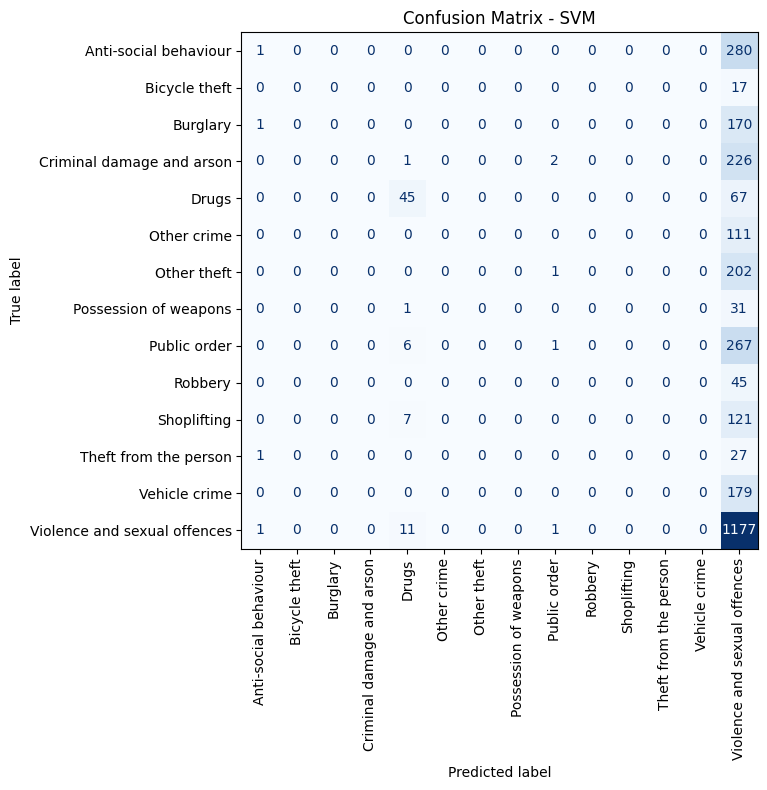

SVM AUC: 0.6820110153570866


In [11]:
svm_model = SVC(
    kernel="linear",
    C=0.5,
    probability=True,
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

svm_pred = svm_model.predict(X_test_processed)
svm_proba = svm_model.predict_proba(X_test_processed)

svm_metrics = get_metrics(y_test, svm_pred, "SVM")
svm_auc = multiclass_auc(y_test, svm_proba, "SVM")
display(pd.DataFrame([svm_metrics]))

print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_, zero_division=0))
plot_confusion(y_test, svm_pred, "Confusion Matrix - SVM")
print("SVM AUC:", svm_auc)


## 9. CNN

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3894 - loss: 1.9718 - val_accuracy: 0.4087 - val_loss: 1.8311
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4031 - loss: 1.8609 - val_accuracy: 0.4097 - val_loss: 1.8179
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4058 - loss: 1.8393 - val_accuracy: 0.4097 - val_loss: 1.8105
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4049 - loss: 1.8303 - val_accuracy: 0.4093 - val_loss: 1.8053
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4070 - loss: 1.8242 - val_accuracy: 0.4100 - val_loss: 1.8019
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4089 - loss: 1.8161 - val_accuracy: 0.4083 - val_loss: 1.8075
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4092 - loss: 1.8162 - val_accuracy: 0.4090 - val_loss: 1.8024
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4077 - loss: 1.8103 - val_accuracy: 0.

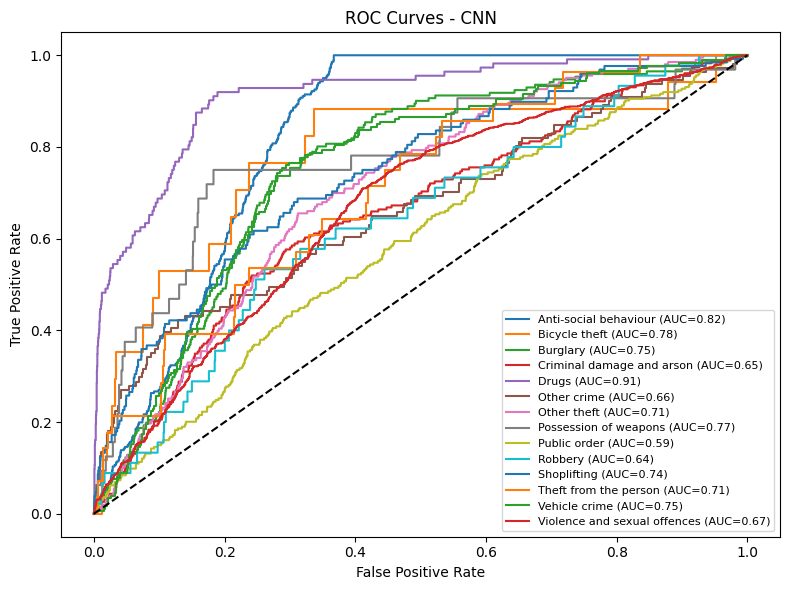

,Model,Accuracy,F1 Score
0,CNN,0.41,0.250183


                              precision    recall  f1-score   support

       Anti-social behaviour       0.00      0.00      0.00       281
               Bicycle theft       0.00      0.00      0.00        17
                    Burglary       0.00      0.00      0.00       171
   Criminal damage and arson       0.00      0.00      0.00       229
                       Drugs       0.67      0.41      0.51       112
                 Other crime       0.00      0.00      0.00       111
                 Other theft       0.00      0.00      0.00       203
       Possession of weapons       0.00      0.00      0.00        32
                Public order       0.00      0.00      0.00       274
                     Robbery       0.00      0.00      0.00        45
                 Shoplifting       0.50      0.05      0.09       128
       Theft from the person       0.00      0.00      0.00        28
               Vehicle crime       0.00      0.00      0.00       179
Violence and sexual

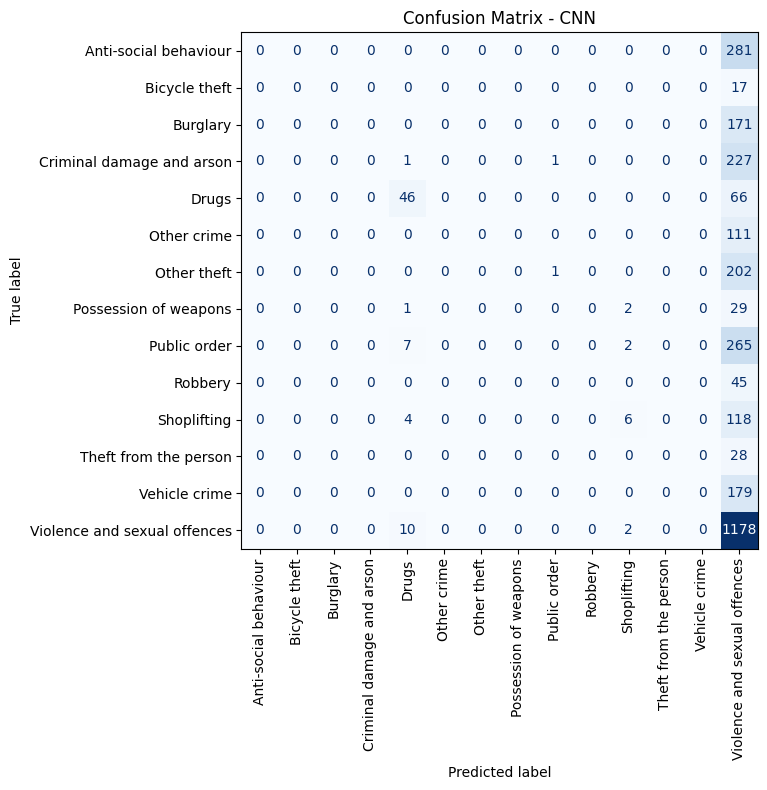

CNN AUC: 0.725915564466806


In [12]:
X_train_cnn = X_train_processed.reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_val_cnn = X_val_processed.reshape(X_val_processed.shape[0], X_val_processed.shape[1], 1)
X_test_cnn = X_test_processed.reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

num_classes = len(np.unique(y_train))
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation="relu", input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

cnn_proba = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_proba, axis=1)

cnn_metrics = get_metrics(y_test, cnn_pred, "CNN")
cnn_auc = multiclass_auc(y_test, cnn_proba, "CNN")
display(pd.DataFrame([cnn_metrics]))

print(classification_report(y_test, cnn_pred, target_names=label_encoder.classes_, zero_division=0))
plot_confusion(y_test, cnn_pred, "Confusion Matrix - CNN")
print("CNN AUC:", cnn_auc)


## 10. Main model comparison

,Model,Accuracy,F1 Score,AUC
0,Random Forest,0.391333,0.265529,0.713775
1,Decision Tree,0.254000,0.258141,0.536553
2,CNN,0.410000,0.250183,0.725916
3,SVM,0.408000,0.246863,0.682011


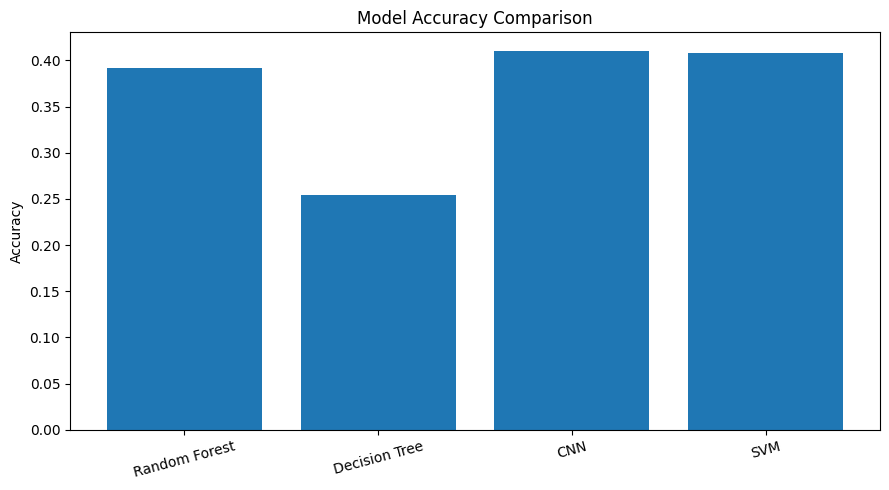

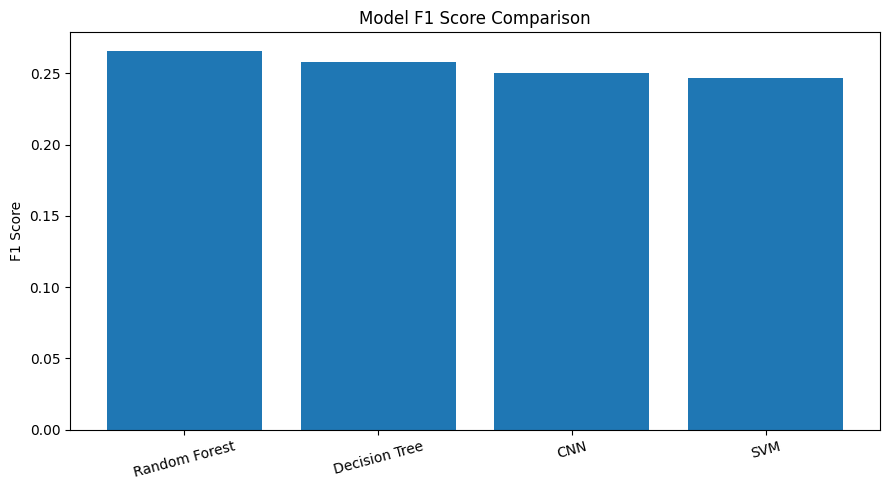

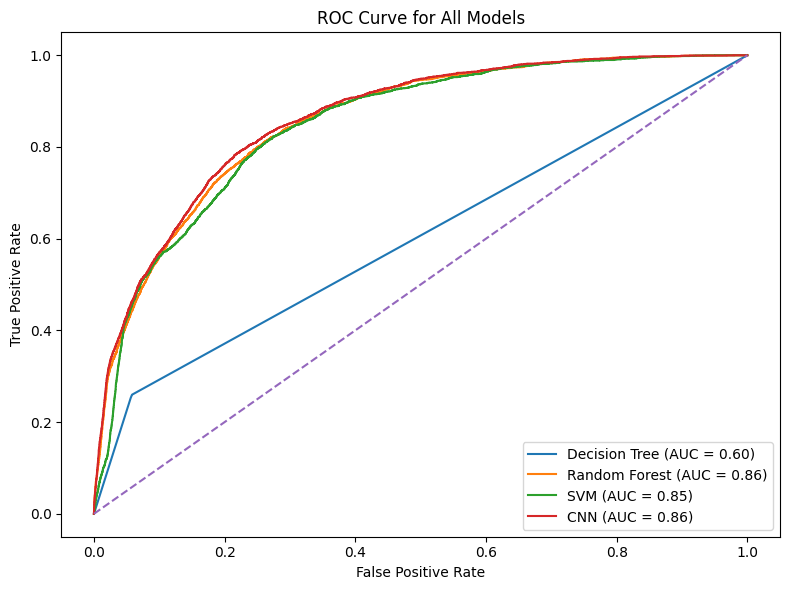

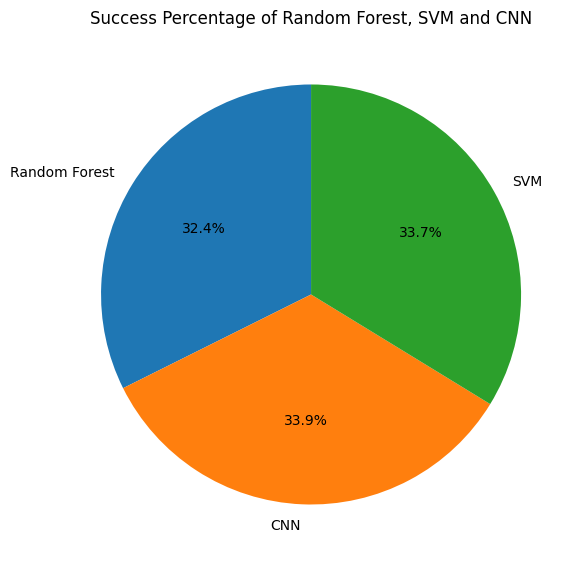

Best main comparison model:
Model       Random Forest
Accuracy         0.391333
F1 Score         0.265529
AUC              0.713775
Name: 0, dtype: object


In [13]:
results = pd.DataFrame([
    {"Model": "Decision Tree", "Accuracy": dt_metrics["Accuracy"], "F1 Score": dt_metrics["F1 Score"], "AUC": dt_auc},
    {"Model": "Random Forest", "Accuracy": rf_metrics["Accuracy"], "F1 Score": rf_metrics["F1 Score"], "AUC": rf_auc},
    {"Model": "SVM", "Accuracy": svm_metrics["Accuracy"], "F1 Score": svm_metrics["F1 Score"], "AUC": svm_auc},
    {"Model": "CNN", "Accuracy": cnn_metrics["Accuracy"], "F1 Score": cnn_metrics["F1 Score"], "AUC": cnn_auc},
]).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

display(results)

plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
plt.figure(figsize=(8, 6))

for name, y_prob in {
    "Decision Tree": dt_proba,
    "Random Forest": rf_proba,
    "SVM": svm_proba,
    "CNN": cnn_proba
}.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Models")
plt.legend()
plt.tight_layout()
plt.show()

pie_df = results[results["Model"].isin(["Random Forest", "SVM", "CNN"])]

plt.figure(figsize=(6, 6))
plt.pie(pie_df["Accuracy"], labels=pie_df["Model"], autopct="%1.1f%%", startangle=90)
plt.title("Success Percentage of Random Forest, SVM and CNN")
plt.tight_layout()
plt.show()

best_main_model = results.iloc[0]
print("Best main comparison model:")
print(best_main_model)


## 11. Advanced section — Feature selection

In [14]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=min(20, X_train_processed.shape[1])
)

X_train_fs = selector.fit_transform(X_train_processed, y_train)
X_val_fs = selector.transform(X_val_processed)
X_test_fs = selector.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("Selected features:", X_train_fs.shape[1])


Original features: 39
Selected features: 20


## 12. Advanced section — SMOTE class balancing

In [15]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_fs, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().sort_index().to_dict())


Before SMOTE: {0: 1312, 1: 80, 2: 797, 3: 1066, 4: 526, 5: 517, 6: 950, 7: 148, 8: 1278, 9: 209, 10: 598, 11: 132, 12: 833, 13: 5554}
After SMOTE: {0: 5554, 1: 5554, 2: 5554, 3: 5554, 4: 5554, 5: 5554, 6: 5554, 7: 5554, 8: 5554, 9: 5554, 10: 5554, 11: 5554, 12: 5554, 13: 5554}


## 13. Advanced section — Hyperparameter tuning for Random Forest

In [16]:
rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid_rf = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_resampled, y_resampled)

tuned_rf = grid_rf.best_estimator_
tuned_rf_pred = tuned_rf.predict(X_test_fs)
tuned_rf_proba = tuned_rf.predict_proba(X_test_fs)

tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred, average="weighted")

print("Best RF params:", grid_rf.best_params_)
print("Tuned RF Accuracy:", tuned_rf_accuracy)
print("Tuned RF F1:", tuned_rf_f1)
print(classification_report(y_test, tuned_rf_pred, target_names=label_encoder.classes_, zero_division=0))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'max_depth': None, 'n_estimators': 200}
Tuned RF Accuracy: 0.231
Tuned RF F1: 0.24543197283492377
                              precision    recall  f1-score   support

       Anti-social behaviour       0.25      0.31      0.27       281
               Bicycle theft       0.03      0.06      0.04        17
                    Burglary       0.15      0.18      0.16       171
   Criminal damage and arson       0.10      0.10      0.10       229
                       Drugs       0.38      0.47      0.42       112
                 Other crime       0.08      0.13      0.09       111
                 Other theft       0.07      0.06      0.07       203
       Possession of weapons       0.07      0.12      0.09        32
                Public order       0.09      0.08      0.08       274
                     Robbery       0.01      0.02      0.02        45
                 Shoplifting       0.12      0.15     

## 14. Advanced section — Neural Network (MLP)

In [17]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_resampled, y_resampled)

mlp_pred = mlp_model.predict(X_test_fs)
mlp_proba = mlp_model.predict_proba(X_test_fs)

mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred, average="weighted")

print("Neural Network Accuracy:", mlp_accuracy)
print("Neural Network F1:", mlp_f1)
print(classification_report(y_test, mlp_pred, target_names=label_encoder.classes_, zero_division=0))


Neural Network Accuracy: 0.15333333333333332
Neural Network F1: 0.15729030407482936
                              precision    recall  f1-score   support

       Anti-social behaviour       0.22      0.48      0.31       281
               Bicycle theft       0.01      0.12      0.02        17
                    Burglary       0.14      0.19      0.16       171
   Criminal damage and arson       0.16      0.05      0.08       229
                       Drugs       0.30      0.47      0.36       112
                 Other crime       0.06      0.12      0.08       111
                 Other theft       0.10      0.08      0.09       203
       Possession of weapons       0.04      0.19      0.07        32
                Public order       0.09      0.02      0.03       274
                     Robbery       0.01      0.09      0.02        45
                 Shoplifting       0.09      0.13      0.11       128
       Theft from the person       0.02      0.11      0.03        28
     

## 15. Advanced section — XGBoost

In [18]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

xgb_pred = xgb_model.predict(X_test_fs)
xgb_proba = xgb_model.predict_proba(X_test_fs)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost F1:", xgb_f1)
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_, zero_division=0))


XGBoost Accuracy: 0.25366666666666665
XGBoost F1: 0.2540339549530805
                              precision    recall  f1-score   support

       Anti-social behaviour       0.23      0.59      0.33       281
               Bicycle theft       0.02      0.12      0.03        17
                    Burglary       0.12      0.14      0.13       171
   Criminal damage and arson       0.18      0.12      0.14       229
                       Drugs       0.33      0.55      0.41       112
                 Other crime       0.14      0.11      0.12       111
                 Other theft       0.12      0.05      0.07       203
       Possession of weapons       0.05      0.12      0.07        32
                Public order       0.11      0.04      0.06       274
                     Robbery       0.04      0.04      0.04        45
                 Shoplifting       0.17      0.18      0.17       128
       Theft from the person       0.04      0.07      0.05        28
               Vehic

## 16. Advanced section — Cross validation

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    tuned_rf,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="f1_weighted"
)

mlp_cv_scores = cross_val_score(
    mlp_model,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="f1_weighted"
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="f1_weighted"
)

cv_results = pd.DataFrame({
    "Model": ["Random Forest (Tuned + SMOTE)", "Neural Network + SMOTE", "XGBoost + SMOTE"],
    "Mean CV F1": [rf_cv_scores.mean(), mlp_cv_scores.mean(), xgb_cv_scores.mean()],
    "Std CV F1": [rf_cv_scores.std(), mlp_cv_scores.std(), xgb_cv_scores.std()]
})

display(cv_results)


,Model,Mean CV F1,Std CV F1
0,Random Forest (Tuned + SMOTE),0.686420,0.001531
1,Neural Network + SMOTE,0.412643,0.005695
2,XGBoost + SMOTE,0.494179,0.002600


## 17. Advanced model comparison and final model selection

,Model,Accuracy,F1 Score,AUC,Mean CV F1
0,XGBoost + SMOTE,0.253667,0.254034,0.704683,0.494179
1,Random Forest (Tuned + SMOTE),0.231000,0.245432,0.652296,0.686420
2,Neural Network + SMOTE,0.153333,0.157290,0.648831,0.412643


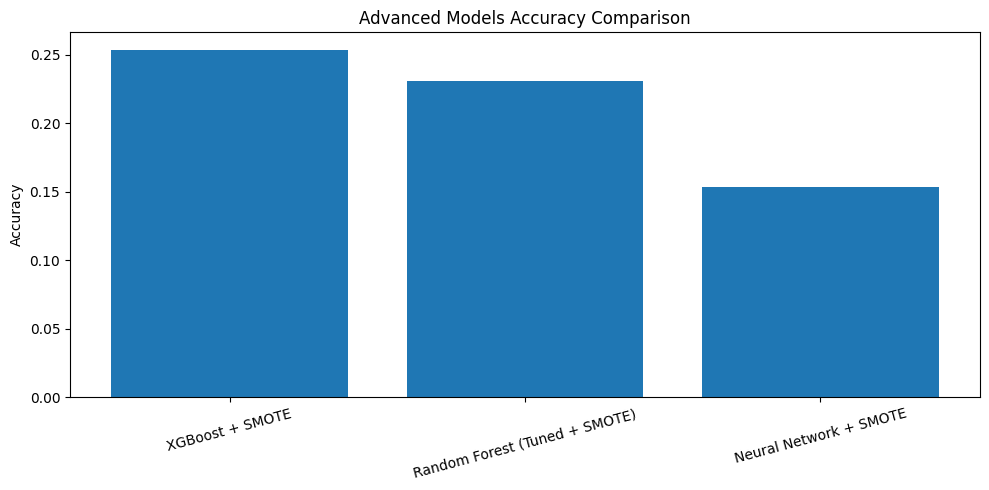

Final selected advanced model: XGBoost + SMOTE


In [20]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

tuned_rf_auc = roc_auc_score(y_test_bin, tuned_rf_proba, average="macro", multi_class="ovr")
mlp_auc = roc_auc_score(y_test_bin, mlp_proba, average="macro", multi_class="ovr")
xgb_auc = roc_auc_score(y_test_bin, xgb_proba, average="macro", multi_class="ovr")

advanced_results = pd.DataFrame([
    {
        "Model": "Random Forest (Tuned + SMOTE)",
        "Accuracy": tuned_rf_accuracy,
        "F1 Score": tuned_rf_f1,
        "AUC": tuned_rf_auc,
        "Mean CV F1": rf_cv_scores.mean()
    },
    {
        "Model": "Neural Network + SMOTE",
        "Accuracy": mlp_accuracy,
        "F1 Score": mlp_f1,
        "AUC": mlp_auc,
        "Mean CV F1": mlp_cv_scores.mean()
    },
    {
        "Model": "XGBoost + SMOTE",
        "Accuracy": xgb_accuracy,
        "F1 Score": xgb_f1,
        "AUC": xgb_auc,
        "Mean CV F1": xgb_cv_scores.mean()
    }
]).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

display(advanced_results)

plt.figure(figsize=(10, 5))
plt.bar(advanced_results["Model"], advanced_results["Accuracy"])
plt.title("Advanced Models Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

final_model_name = advanced_results.iloc[0]["Model"]
print("Final selected advanced model:", final_model_name)


## 18. Prediction pipeline

In [21]:
def predict_new_crime(sample_dict):
    sample_df = pd.DataFrame([sample_dict])

    for col in X.columns:
        if col not in sample_df.columns:
            sample_df[col] = np.nan

    sample_df = sample_df[X.columns]

    transformed = preprocessor.transform(sample_df)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    transformed = selector.transform(transformed)

    if final_model_name == "Random Forest (Tuned + SMOTE)":
        pred = tuned_rf.predict(transformed)[0]
    elif final_model_name == "Neural Network + SMOTE":
        pred = mlp_model.predict(transformed)[0]
    else:
        pred = xgb_model.predict(transformed)[0]

    return label_encoder.inverse_transform([pred])[0]

print("Prediction pipeline ready.")
print("Input columns:", list(X.columns))


Prediction pipeline ready.
Input columns: ['Latitude', 'Longitude', 'Year', 'Month_num', 'Quarter', 'LSOA code', 'Last outcome category']


## 19. Example prediction

In [22]:
example_input = {}

for col in X.columns:
    if col == "Latitude":
        example_input[col] = 53.8
    elif col == "Longitude":
        example_input[col] = -1.75
    elif col == "Year":
        example_input[col] = 2025
    elif col == "Month_num":
        example_input[col] = 8
    elif col == "Quarter":
        example_input[col] = 3
    else:
        example_input[col] = np.nan

print("Predicted crime type:", predict_new_crime(example_input))


Predicted crime type: Anti-social behaviour
